**Decision Tree**
Team members: LMV N1

*   Rocío Sánchez Solórzano 2043109
*   Karen Melissa Morales Moya 2043909
*   Hugo Fernando Nuncio Álvarez 2104134
*   Juan Gerardo Torres Flores 2074382





1. Load Libraries

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn import tree
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import seaborn as sns
import numpy as np

2. Load Data

In [4]:
breast_cancer = load_breast_cancer()
x = breast_cancer.data
y = breast_cancer.target

In [20]:
#target names from dataset
breast_cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

3. Data preprocessing


In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

4. Model selection and training.

In [7]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [22]:
#accuracy of the model in training
train_accuracy = clf.score(x_train,y_train)
print(train_accuracy)

1.0


5. Model Testing

In [13]:
y_predict = clf.predict(x_test)

In [21]:
#get confusion matrix
conf_matrix = confusion_matrix(y_test,y_predict)

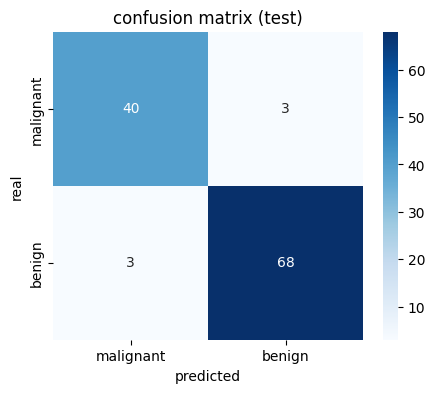

In [25]:
#display the confusion matrix for the test results
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',xticklabels=['malignant','benign'],yticklabels=['malignant','benign'])
plt.xlabel('predicted')
plt.ylabel('real')
plt.title('confusion matrix (test)')
plt.show()

In [26]:
for i in range(5):
  print('predict: ',i)
  print(y_predict[i])
  print(y_test[i],'\n')

predict:  0
1
1 

predict:  1
0
0 

predict:  2
0
0 

predict:  3
1
1 

predict:  4
1
1 



In [27]:
#general accuarcy report
accuracy = accuracy_score(y_test,y_predict)
print('accuracy:', accuracy)
print('classification report:\n',classification_report(y_test,y_predict,target_names=breast_cancer.target_names))

accuracy: 0.9473684210526315
classification report:
               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



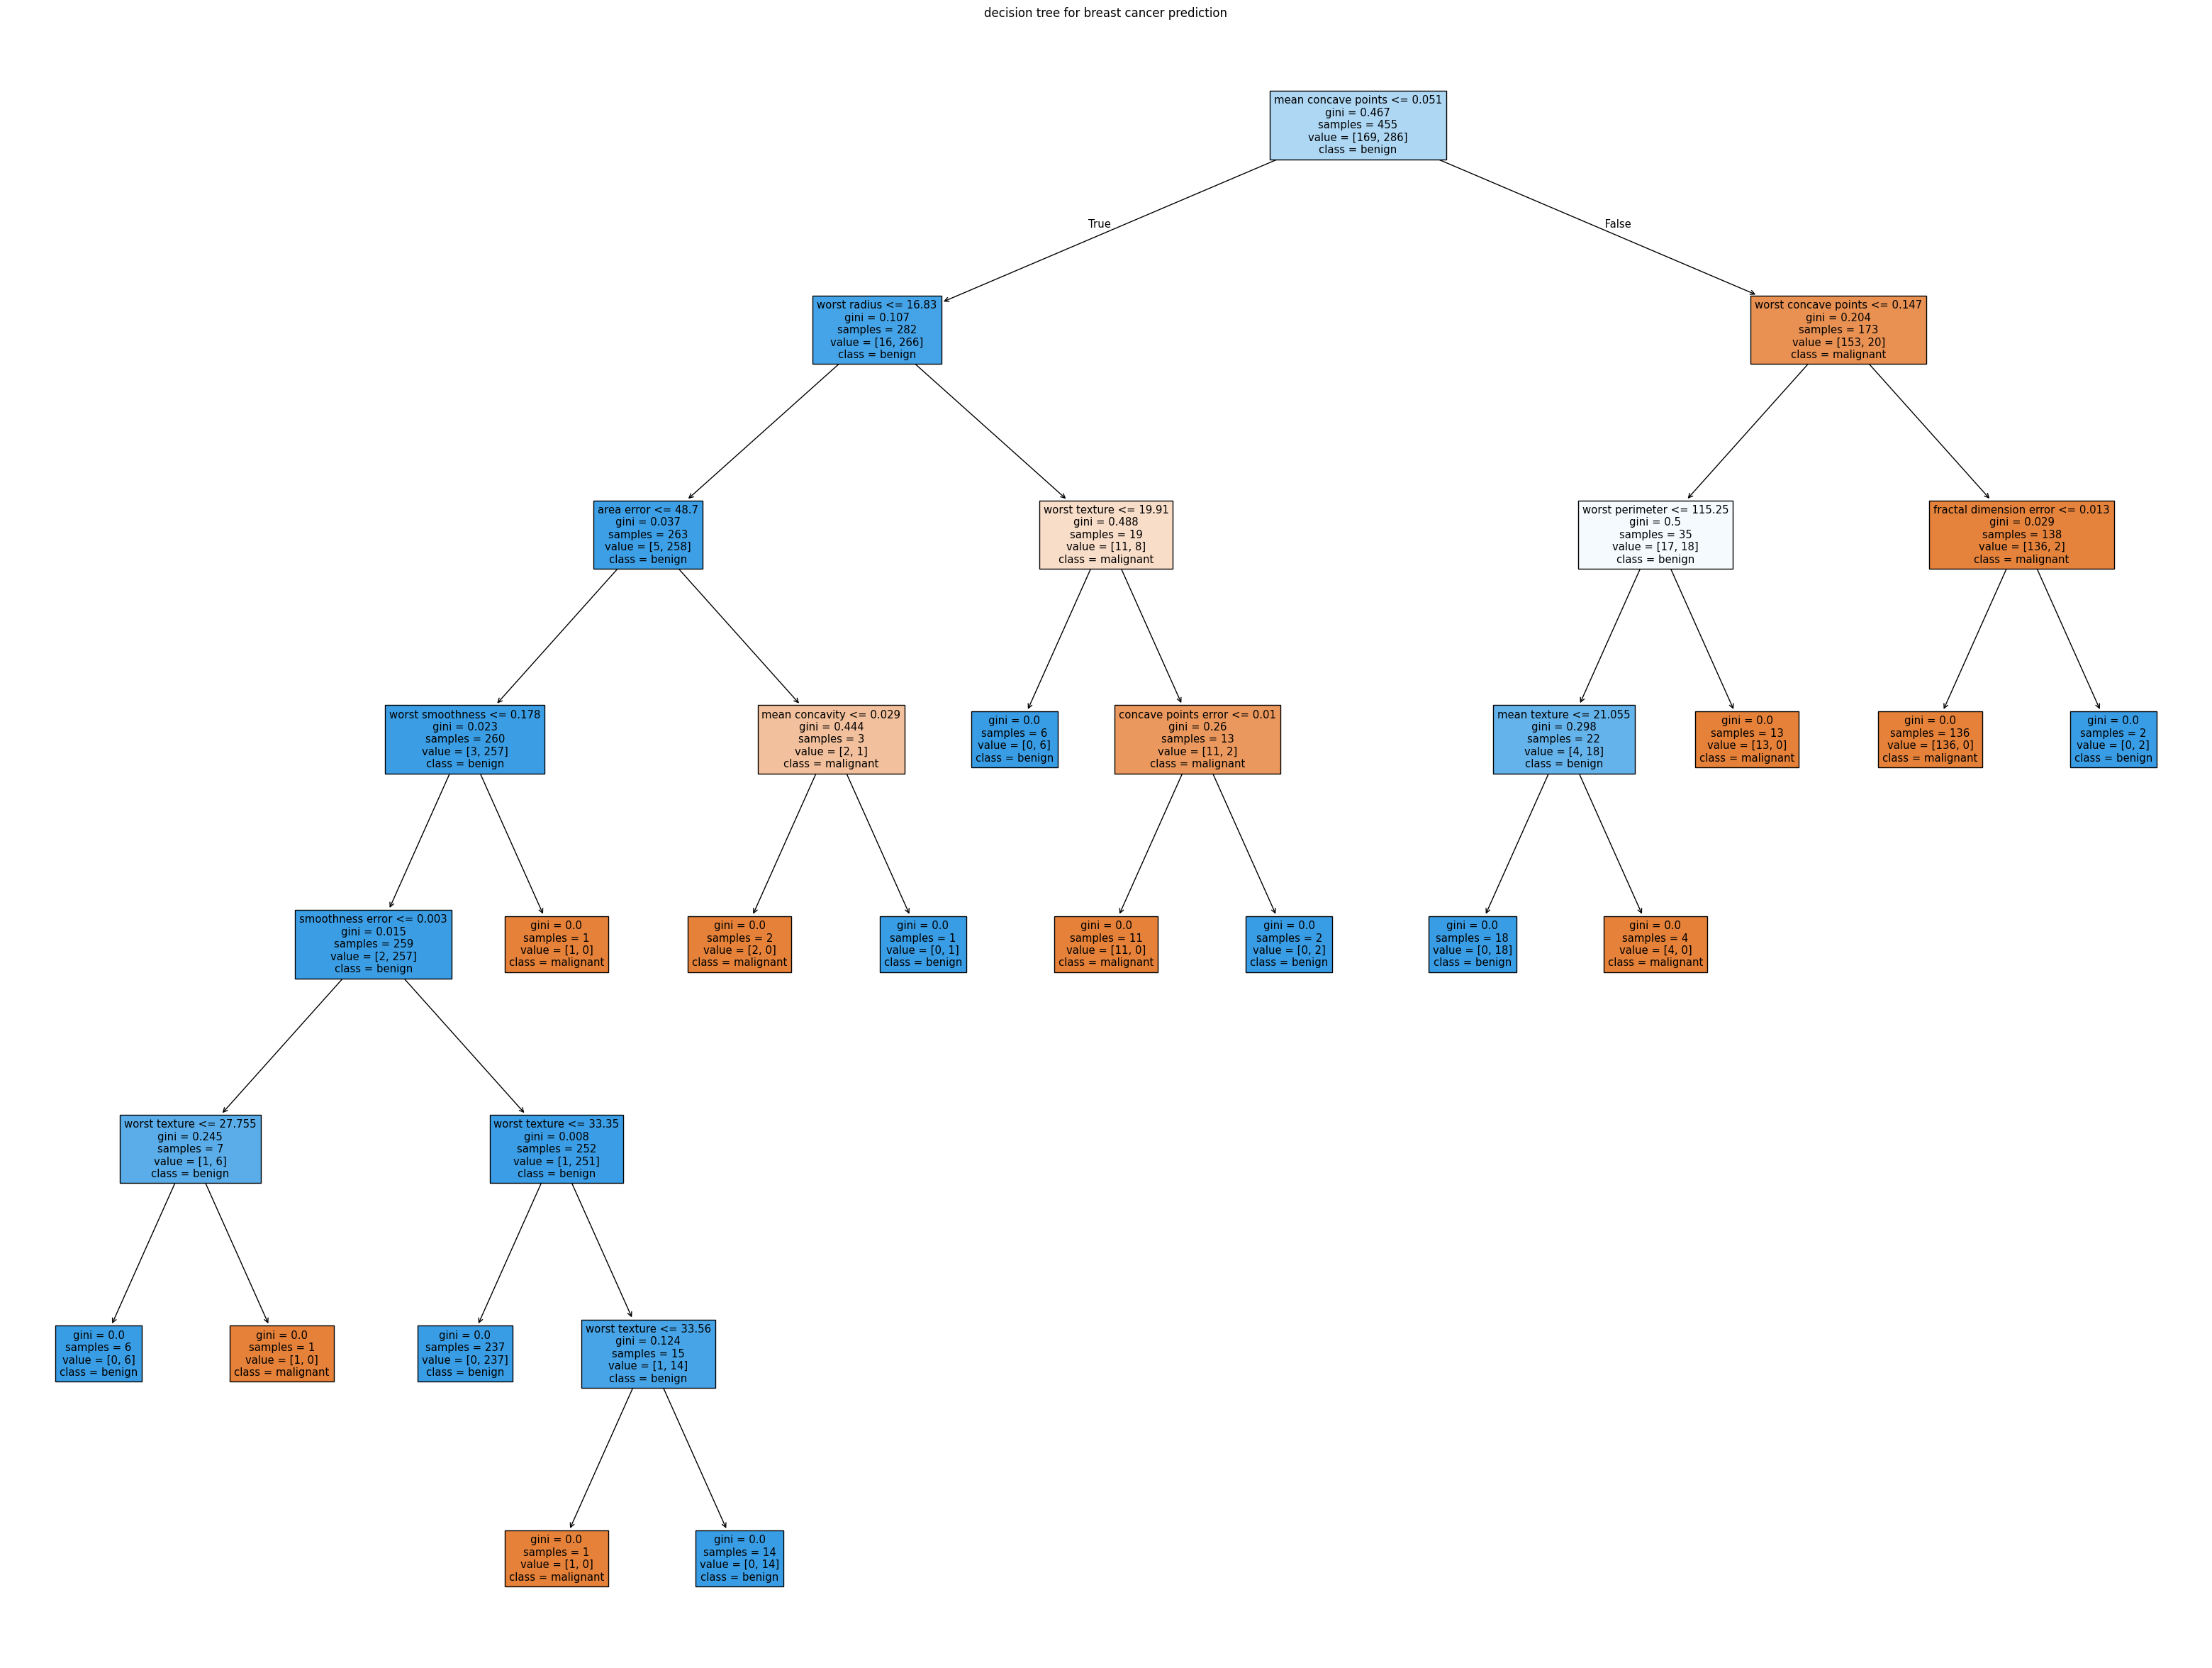

In [28]:
#decision tree graph
plt.figure(figsize=(40,30))
tree.plot_tree(clf,filled=True,feature_names=breast_cancer.feature_names,class_names=breast_cancer.target_names)
plt.title('decision tree for breast cancer prediction')
plt.savefig('decision_tree.png',dpi=300)
plt.show()